In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [26]:
df = pd.read_csv(r'house_price_regression_dataset.csv')

In [27]:
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [28]:
df.shape

(1000, 8)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [30]:
df.isna().sum()

Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

In [31]:
df.duplicated().sum()

np.int64(0)

In [32]:
df['House_Price'] = df['House_Price'].astype(int)

In [33]:
df['House_Price']

0       262382
1       985260
2       777977
3       229698
4      1041740
        ...   
995     701493
996     683723
997     572024
998     964865
999     742599
Name: House_Price, Length: 1000, dtype: int64

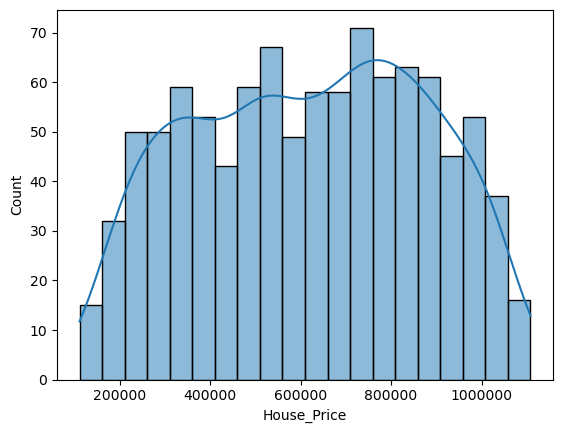

In [34]:
sns.histplot(x=df['House_Price'],kde=True,bins=20)
plt.ticklabel_format(style='plain', axis='x')

<Axes: >

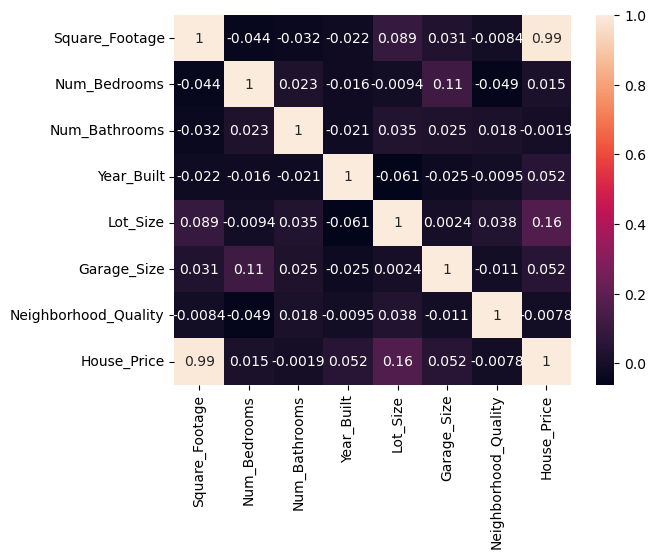

In [35]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

<Axes: xlabel='Square_Footage', ylabel='House_Price'>

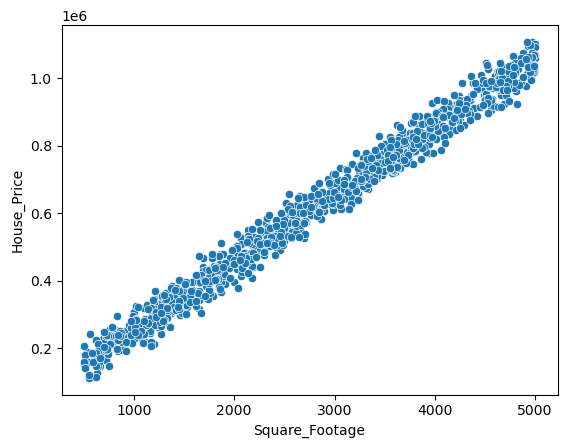

In [49]:
sns.scatterplot(data=df, x='Square_Footage', y='House_Price')

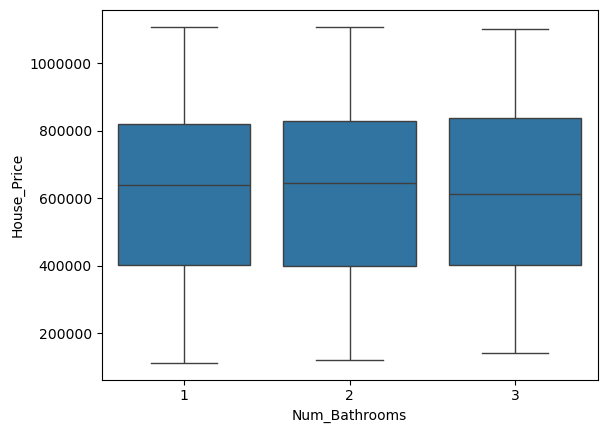

In [53]:

sns.boxplot(data=df, x='Num_Bathrooms', y='House_Price')

plt.ticklabel_format(style='plain', axis='y')
plt.show()


In [50]:
df.columns

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_size', 'Neighborhood_Quality', 'House_Price'],
      dtype='object')

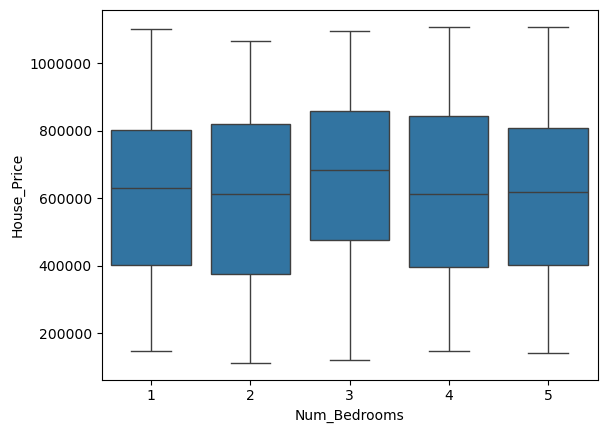

In [54]:

sns.boxplot(data=df, x='Num_Bedrooms', y='House_Price')

plt.ticklabel_format(style='plain', axis='y')
plt.show()


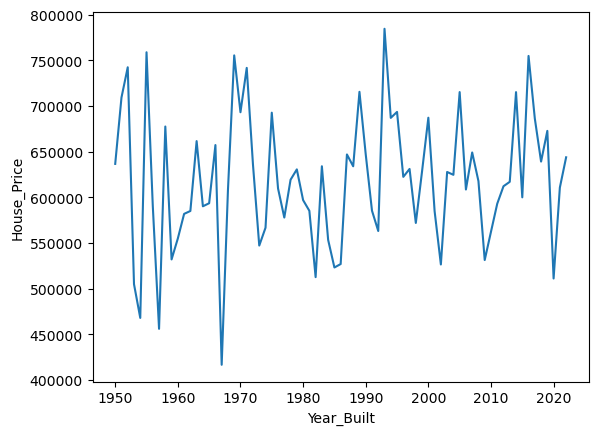

In [60]:
sns.lineplot(data=df, x='Year_Built', y='House_Price', errorbar=None)

plt.ticklabel_format(style='plain', axis='y')
plt.show()

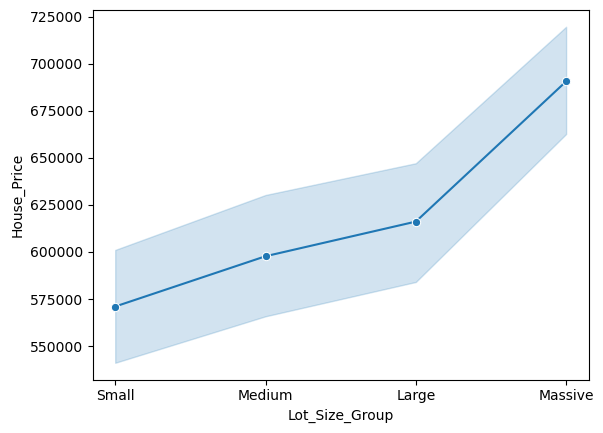

In [65]:
df['Lot_Size_Group'] = pd.qcut(df['Lot_Size'], q=4, labels=['Small', 'Medium', 'Large', 'Massive'])

sns.lineplot(data=df, x='Lot_Size_Group', y='House_Price', marker='o')

plt.ticklabel_format(style='plain', axis='y')
plt.show()

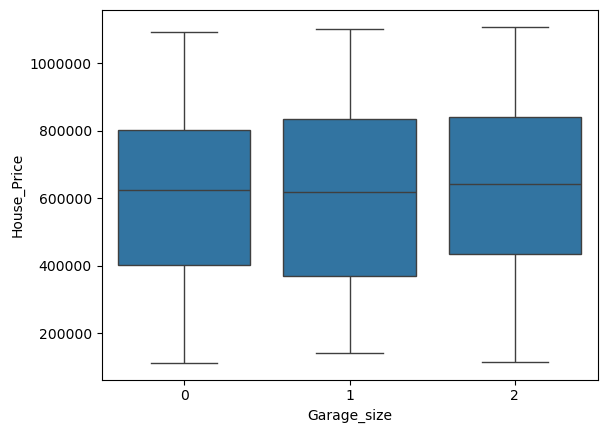

In [70]:
sns.boxplot(data=df, x='Garage_size', y='House_Price')

plt.ticklabel_format(style='plain', axis='y')
plt.show()


<Axes: xlabel='Neighborhood_Quality', ylabel='House_Price'>

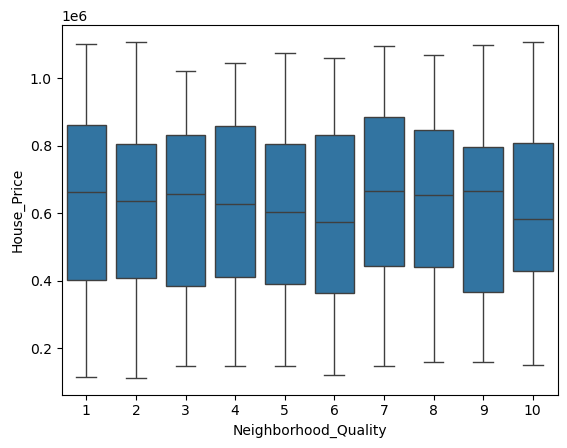

In [72]:
sns.boxplot(data=df, x='Neighborhood_Quality', y='House_Price')

In [82]:
X = df.drop('House_Price', axis=1)

In [83]:
y = df['House_Price']

In [77]:
X

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_size,Neighborhood_Quality,Lot_Size_Group
0,1360,2,1,1981,0.599637,0,5,Small
1,4272,3,3,2016,4.753014,1,6,Massive
2,3592,1,2,2016,3.634823,0,9,Large
3,966,1,2,1977,2.730667,1,8,Medium
4,4926,2,1,1993,4.699073,0,8,Massive
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,Medium
996,3179,1,2,1999,2.977123,1,10,Large
997,2606,4,2,1962,4.055067,0,2,Massive
998,4723,5,2,1950,1.930921,0,7,Medium


In [88]:
X = pd.get_dummies(X, drop_first=True)

bool_cols = X.select_dtypes(bool).columns

X[bool_cols] = X[bool_cols].astype(int)

In [89]:
X

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_size,Neighborhood_Quality,Lot_Size_Group_Medium,Lot_Size_Group_Large,Lot_Size_Group_Massive
0,1360,2,1,1981,0.599637,0,5,0,0,0
1,4272,3,3,2016,4.753014,1,6,0,0,1
2,3592,1,2,2016,3.634823,0,9,0,1,0
3,966,1,2,1977,2.730667,1,8,1,0,0
4,4926,2,1,1993,4.699073,0,8,0,0,1
...,...,...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,1,0,0
996,3179,1,2,1999,2.977123,1,10,0,1,0
997,2606,4,2,1962,4.055067,0,2,0,0,1
998,4723,5,2,1950,1.930921,0,7,1,0,0


In [87]:
X

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_size,Neighborhood_Quality,Lot_Size_Group_Medium,Lot_Size_Group_Large,Lot_Size_Group_Massive
0,1360,2,1,1981,0.599637,0,5,False,False,False
1,4272,3,3,2016,4.753014,1,6,False,False,True
2,3592,1,2,2016,3.634823,0,9,False,True,False
3,966,1,2,1977,2.730667,1,8,True,False,False
4,4926,2,1,1993,4.699073,0,8,False,False,True
...,...,...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,True,False,False
996,3179,1,2,1999,2.977123,1,10,False,True,False
997,2606,4,2,1962,4.055067,0,2,False,False,True
998,4723,5,2,1950,1.930921,0,7,True,False,False


In [97]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [99]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)

n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1-((1-r2)*(n-1)/(n-p-1))

In [100]:
y_test

521     901000
737     494537
740     949404
660    1040389
411     794010
        ...   
408     824529
332     180393
208     965816
613     433664
78      663904
Name: House_Price, Length: 200, dtype: int64

In [101]:
r2

0.9984124165823202

In [102]:
adjusted_r2

0.9983284174596916

In [103]:
y_pred

array([ 869079.01064574,  489990.42262345,  946382.38533087,
       1033893.93200398,  777725.47732871,  732505.05622767,
        994486.94687133,  885070.96689193,  796217.56872572,
        932193.15018702,  758653.55340413,  645936.32557433,
        217634.50429792, 1047519.45615943,  536885.12414068,
        188712.62044771,  457319.60116573,  358578.42954669,
        742651.74426566,  361880.8794005 ,  776017.78343132,
        478147.13007916,  681306.83499305,  889937.26308864,
        447366.18084776,  395803.36331102,  455066.66902795,
        443220.37446578,  187860.54187686,  492722.44536273,
        279952.82074471,  896563.33450378,  784278.28449419,
        352949.87925214,  479471.738258  ,  766934.95030351,
        475666.05268557,  573377.42787206,  303926.9808278 ,
        155078.01360404,  304345.4617685 ,  298595.27018996,
        507612.76951968,  309756.10905955, 1081009.1615493 ,
       1011359.08180856,  760557.17437532,  806772.42865324,
       1026072.0705906 ,